# Expectation-Maximization (EM) algorithm

The **Expectation-Maximization (EM) algorithm** is an iterative method for maximum likelihood (or maximum a posteriori) estimation in models with latent variables or incomplete data. Its key insight is that if the complete data (observed plus missing values) were available, parameter estimation would be straightforward using complete-data sufficient statistics.

EM alternates between:

- **E-step (Expectation):** Estimate the missing or latent data (typically, compute the posterior probability $p(z|x,\theta^{(t)})$).
- **M-step (Maximization):** Update the parameters by maximizing the expected complete-data log-likelihood.

This iterative process continues until convergence. Despite its attractive monotonicity properties, EM can be sensitive to initialization and may converge slowly; thus, numerous extensions have been developed.

**Intuitive Flow**

1. **Initialization:** Choose starting values for the parameters (using, e.g., domain knowledge or clustering).
2. **E-step:** Compute the expectation of the complete-data log-likelihood (i.e., the Q-function) using $q(z)=p(z|x,\theta^{(t)})$.
3. **M-step:** Update the parameters by maximizing this Q-function.
4. **Convergence Check:** Determine whether the log-likelihood (or parameter estimates) has converged; if not, repeat.

This cycle iteratively refines the parameter estimates until the algorithm converges.

## 2. Theoretical Foundations and Derivations

### 2.1 The Missing Information Principle and KL Divergence

Let $x$ be the observed data and $z$ be the latent (or missing) data. The observed-data log-likelihood is

$$
\ell(\theta)=\log p(x|\theta)=\log\int p(x,z|\theta)\,dz.
$$ 

By introducing an auxiliary distribution $q(z)=p(z|x,\theta^{(t)})$, we can decompose it as:

$$
\log p(x|\theta)=Q(\theta|\theta^{(t)})+\mathrm{KL}(p(z|x,\theta^{(t)})\parallel p(z|x,\theta)),
$$

where the **Q function** is defined as

$$
Q(\theta|\theta^{(t)})=\int p(z|x,\theta^{(t)})\log p(x,z|\theta)\,dz.
$$ 

Since the KL divergence is always nonnegative, $Q(\theta|\theta^{(t)})$ is a lower bound on $\log p(x|\theta)$, ensuring that the likelihood does not decrease between iterations.

### 2.2 Coordinate Ascent and Variational Extensions (VB‑EM)

EM can be seen as coordinate ascent on the variational lower bound

$$
F(q,\theta)=\int q(z)\log \frac{p(x,z|\theta)}{q(z)}\,dz.
$$ 

In the E-step, we set $q(z)=p(z|x,\theta^{(t)})$ to maximize $F$ with respect to $q$. In the M-step, we maximize $F$ with respect to $\theta$. This interpretation leads directly to **Variational EM (VB‑EM)**, where an approximate posterior $q(z)$ (often from a family that factorizes) is used when the true posterior is intractable.

### 2.3 Convergence Behavior and Asymptotic Properties

Under regularity conditions (e.g., Wu (1983)), the EM algorithm produces a sequence in which the observed-data log-likelihood is non-decreasing and eventually converges to a stationary point.

**Key Points:**

- **Monotonicity:** Every EM iteration guarantees that the log-likelihood does not decrease.
- **Local Convergence Rate:** The rate is determined by the fraction of missing information. It is often characterized by the matrix

$$D=I-I_{obs}^{-1}I_{aug},$$

where $I_{obs}$ is the observed Fisher information and $I_{aug}$ is the complete-data Fisher information. A smaller maximum eigenvalue of $D$ indicates faster convergence.
- **Asymptotic Normality:** With additional regularity conditions, the ML estimates obtained via EM are consistent and asymptotically normal with covariance $I_{obs}^{-1}$.

### 2.4 Numerical Stability: The Log-Sum-Exp Trick

Since EM often requires summing very small probabilities, numerical underflow may occur. To mitigate this, it is common to use the log-sum-exp trick:

$$\log \sum_i \exp(a_i) \approx a_{\text{max}}+\log \sum_i \exp(a_i-a_{\text{max}}),$$

which allows for more stable computations.

In [1]:
import numpy as np

def log_sum_exp(a):
    a_max = np.max(a)
    return a_max + np.log(np.sum(np.exp(a - a_max)))

a = np.array([-1000, -1001, -1002])
print('log-sum-exp:', log_sum_exp(a))

log-sum-exp: -999.5923940355556


## 3. Practical Implementation Considerations and Issues

Implementing EM requires attention to several practical details:

### 3.1 Initialization

- **Sensitivity:** The algorithm is sensitive to initial parameter estimates. Poor initialization can lead to convergence to suboptimal local maxima.
- **Strategies:** Use domain knowledge, perform multiple random starts, or initialize using methods like k-means (for GMMs).

### 3.2 Convergence Criteria and Diagnostics

- **Stopping Criteria:** Monitor the change in the log-likelihood or parameter estimates; stop when the change falls below a threshold.
- **Visualization:** Plot the log-likelihood over iterations to diagnose convergence behavior.

### 3.3 Numerical Stability

- Use log-domain computations (e.g., the log-sum-exp trick) to avoid underflow.
- Employ scaling techniques, especially in models like HMMs.

### 3.4 Computational Efficiency

- **Vectorization:** Use optimized libraries (such as NumPy) to perform vectorized operations.
- **Sampling:** In variants like MCEM, balance the number of Monte Carlo samples between accuracy and computational cost.
- **Stochastic Updates:** Consider using SAEM in large-scale or streaming data contexts.

### 3.5 Software and Libraries

Leverage robust implementations from libraries such as:
- **scikit-learn:** For Gaussian Mixture Models, Factor Analysis, and IterativeImputer.
- **hmmlearn:** For Hidden Markov Models.


## 4. Extensions and Variants of EM

Beyond the basic EM algorithm, many variants have been developed to address specific challenges or improve convergence:

### 4.1 Variational EM (VB‑EM)

**Idea:** Use a tractable approximate posterior $q(z)$ to maximize the variational lower bound

$$
F(q,\theta)=\int q(z) \log \frac{p(x,z|\theta)}{q(z)} dz.
$$ 

**Applications:** Applicable when $p(z|x,\theta)$ is intractable (e.g., in Latent Dirichlet Allocation).


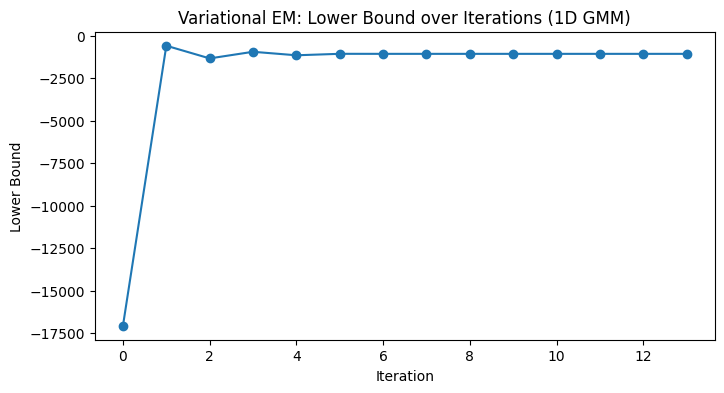

In [2]:
import numpy as np
from scipy.special import digamma

def vb_em_gmm_1d(X, K=2, max_iter=100, tol=1e-4):
    n = X.shape[0]
    q = np.full((n, K), 1.0/K)  # Uniform initial responsibilities
    alpha = np.ones(K)         # Dirichlet parameters for mixing weights
    mu = np.random.choice(X.ravel(), K)
    beta = np.ones(K)          # Precision parameters for means
    a = np.ones(K)             # Shape parameters for variance estimates
    b = np.ones(K)             # Scale parameters for variance estimates
    
    lower_bounds = []
    for iteration in range(max_iter):
        for i in range(n):
            for k in range(K):
                log_q = (digamma(alpha[k]) - digamma(np.sum(alpha))) \
                         - 0.5*(np.log(b[k]) + np.log(2*np.pi)) \
                         - 0.5*beta[k]*(X[i, 0]-mu[k])**2
                q[i, k] = np.exp(log_q)
            total = np.sum(q[i, :])
            # Prevent division by zero by setting a lower bound (epsilon)
            epsilon = 1e-12
            if total < epsilon:
                total = epsilon
            q[i, :] /= total
        
        Nk = np.sum(q, axis=0)
        alpha = 1 + Nk
        for k in range(K):
            mu[k] = np.sum(q[:, k] * X[:, 0]) / Nk[k]
            beta[k] = 1.0 + Nk[k]
            a[k] = 1.0 + Nk[k] / 2
            b[k] = 1.0 + 0.5 * np.sum(q[:, k] * (X[:, 0] - mu[k])**2)
        
        lower_bound = 0.0
        for i in range(n):
            for k in range(K):
                lower_bound += q[i, k] * (digamma(alpha[k]) - digamma(np.sum(alpha)) \
                                     - 0.5*(np.log(b[k]) + np.log(2*np.pi)) \
                                     - 0.5*beta[k]*(X[i]-mu[k])**2 - np.log(q[i, k] + 1e-10))
        lower_bounds.append(lower_bound)
        if iteration > 0 and abs(lower_bounds[-1] - lower_bounds[-2]) < tol:
            break
    return alpha, mu, beta, a, b, lower_bounds, q

# Assume X_1d is defined (1D data) and run VB-EM
# For demonstration, we create some synthetic 1D data
np.random.seed(42)
X_1d = np.concatenate([np.random.normal(0, 1, 100), np.random.normal(5, 1.5, 100)]).reshape(-1, 1)
alpha_vb, mu_vb, beta_vb, a_vb, b_vb, lower_bounds, q_vb = vb_em_gmm_1d(X_1d, K=2)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(lower_bounds, marker='o')
plt.title('Variational EM: Lower Bound over Iterations (1D GMM)')
plt.xlabel('Iteration')
plt.ylabel('Lower Bound')
plt.show()


### 4.2 MAP EM (Incorporating Priors)

MAP EM modifies the EM algorithm by incorporating a prior $p(\theta)$ on the parameters. The complete-data log-posterior is

$$\log p(\theta|x,z)=\log p(x,z|\theta)+\log p(\theta),$$

so the Q-function becomes:

$$Q_{\text{MAP}}(\theta|\theta^{(t)})=E_{z|x,\theta^{(t)}}[\log p(x,z|\theta)] + \log p(\theta).$$

In [3]:
def update_mean_MAP(X, r, mu_prior, sigma2_prior, sigma2_component):
    """
    MAP update for the mean of a Gaussian component with a Gaussian prior.
    """
    N_eff = np.sum(r)
    var_post = 1 / (N_eff/sigma2_component + 1/sigma2_prior)
    mu_post = var_post * (np.sum(r * X) / sigma2_component + mu_prior/sigma2_prior)
    return mu_post

# Example usage:
X_sample = np.array([0.5, -0.2, 1.0, 0.8])
r_sample = np.array([0.7, 0.6, 0.8, 0.9])
mu_prior = 0.0
sigma2_prior = 1.0
sigma2_component = 0.5
mu_updated = update_mean_MAP(X_sample, r_sample, mu_prior, sigma2_prior, sigma2_component)
print('MAP updated mean:', mu_updated)

MAP updated mean: 0.5000000000000001


### 4.3 ECM, ECME, and PX‑EM

These variants modify the M-step of EM:

- **ECM:** Splits the M-step into multiple conditional maximization (CM) steps by partitioning the parameters.
- **ECME:** In some CM steps, the observed-data log-likelihood is directly maximized.
- **PX‑EM:** Introduces auxiliary parameters to expand the parameter space and reduce missing information, which may accelerate convergence.

#### Pseudocode Example for ECM:

```python
# Pseudocode for an ECM algorithm:
for t in range(max_iter):
    q = compute_posterior(x, theta[t])  # E-step
    theta1_new = argmax_{theta1} Q(theta1, theta2; theta[t])  # CM-step for first block
    theta2_new = argmax_{theta2} Q(theta1_new, theta2; theta[t])  # CM-step for second block
    theta[t+1] = (theta1_new, theta2_new)
    if convergence(theta[t+1], theta[t]):
        break
```
```


### 4.4 Monte Carlo EM (MCEM) and Stochastic Approximation EM (SAEM)

**MCEM:** Approximate the E-step by drawing samples $\{z^{(i)}\}_{i=1}^M$ from $p(z|x,\theta^{(t)})$, so that

$$E[\log p(x,z|\theta)] \approx \frac{1}{M}\sum_{i=1}^M \log p(x,z^{(i)}|\theta).$$

**SAEM:** Uses mini-batch updates to handle large-scale or streaming data.


In [4]:
def gaussian_pdf(x, mu, sigma):
    """
    Compute the probability density function of a Gaussian (Normal) distribution.
    
    Parameters:
    x : array-like
        The data points.
    mu : float
        The mean.
    sigma : float
        The standard deviation.
    
    Returns:
    pdf : array-like
        The probability densities of x.
    """
    return (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

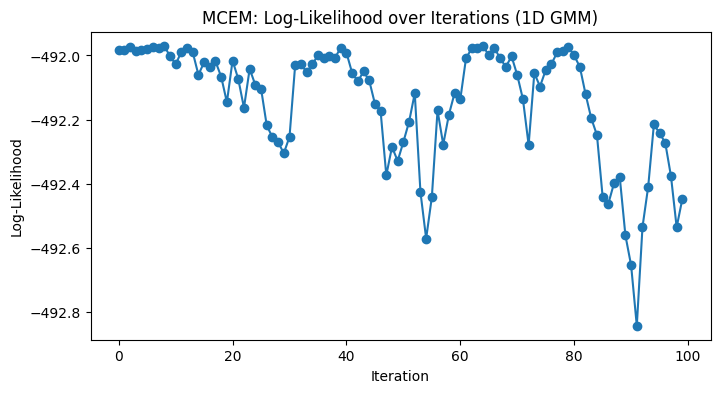

In [5]:
def mcem_gmm_1d(X, mu, sigma, pi, n_samples_mc=50, max_iter=100, tol=1e-4):
    n = X.shape[0]
    log_likelihoods = []
    for iteration in range(max_iter):
        r = np.zeros((n, 2))
        for i in range(n):
            samples = np.random.choice(2, size=n_samples_mc, p=[pi[0], pi[1]])
            for k in range(2):
                r[i, k] = np.sum(samples == k) / n_samples_mc
        
        N_k = r.sum(axis=0)
        mu = (r.T @ X[:, 0]) / N_k
        sigma = np.sqrt((r.T @ ((X[:, 0].reshape(-1, 1) - mu)**2)) / N_k).flatten()
        pi = N_k / n
        
        comp_ll = np.zeros((n, 2))
        for k in range(2):
            comp_ll[:, k] = pi[k] * gaussian_pdf(X[:, 0], mu[k], sigma[k])
        ll = np.sum(np.log(comp_ll.sum(axis=1)))
        log_likelihoods.append(ll)
        
        if iteration > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            break
    return mu, sigma, pi, log_likelihoods

# Generate synthetic 1D data if not already defined
np.random.seed(42)
X_1d = np.concatenate([np.random.normal(0, 1, 100), np.random.normal(5, 1.5, 100)]).reshape(-1, 1)

# Assume initial parameters mu, sigma, pi
mu_init = np.array([np.min(X_1d), np.max(X_1d)])
sigma_init = np.array([1.0, 1.0])
pi_init = np.array([0.5, 0.5])

mu_est_mcem, sigma_est_mcem, pi_est_mcem, ll_history_mcem = mcem_gmm_1d(X_1d, mu_init.copy(), sigma_init.copy(), pi_init.copy())
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(ll_history_mcem, marker='o')
plt.title('MCEM: Log-Likelihood over Iterations (1D GMM)')
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.show()


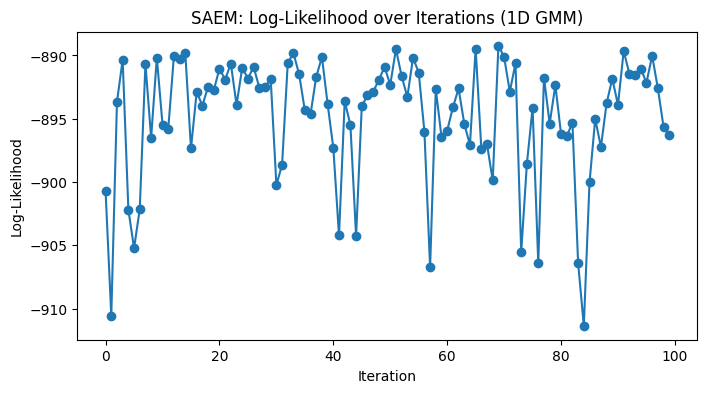

Estimated means: [0.06857351 4.93127816]
Estimated sigmas: [0.89476591 1.7092566 ]
Estimated mixing coefficients: [0.42895581 0.57104419]


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def saem_gmm_1d(X, K=2, max_iter=100, tol=1e-4, batch_size=50, step_size=0.5):
    """
    A simple SAEM implementation for a 1D Gaussian Mixture Model.
    This example uses mini-batch stochastic updates.
    Parameters:
        X: data array of shape (n_samples, 1)
        K: number of mixture components
        max_iter: maximum number of iterations
        tol: convergence tolerance based on log-likelihood change
        batch_size: mini-batch size for stochastic updates
        step_size: learning rate for updating parameters
    Returns:
        mu, sigma, pi: estimated means, standard deviations, and mixing coefficients
        ll_history: log-likelihood history
    """
    n = X.shape[0]
    # Initialization (using simple random choices or heuristics)
    mu = np.random.choice(X.ravel(), K)
    sigma = np.ones(K)
    pi = np.ones(K) / K
    ll_history = []
    
    for iteration in range(max_iter):
        # Select a mini-batch of indices randomly
        indices = np.random.choice(n, batch_size, replace=False)
        X_batch = X[indices, 0]  # Work with 1D array for convenience
        
        # E-step: compute responsibilities for the mini-batch
        r = np.zeros((batch_size, K))
        for i in range(batch_size):
            for k in range(K):
                r[i, k] = pi[k] * (1 / (np.sqrt(2 * np.pi) * sigma[k])) * \
                          np.exp(-0.5 * ((X_batch[i] - mu[k]) / sigma[k]) ** 2)
            r[i, :] /= np.sum(r[i, :])
        
        # M-step: compute parameter updates for the mini-batch
        Nk = np.sum(r, axis=0)
        # Update using a step size (stochastic gradient-style update)
        for k in range(K):
            mu_update = np.sum(r[:, k] * X_batch) / Nk[k] - mu[k]
            mu[k] += step_size * mu_update
            
            sigma_update = np.sqrt(np.sum(r[:, k] * (X_batch - mu[k]) ** 2) / Nk[k]) - sigma[k]
            sigma[k] += step_size * sigma_update
            
            pi_update = Nk[k] / batch_size - pi[k]
            pi[k] += step_size * pi_update
        
        # Ensure probabilities are normalized and sigma is positive
        pi = np.maximum(pi, 1e-10)
        pi /= np.sum(pi)
        sigma = np.maximum(sigma, 1e-3)
        
        # Evaluate full log-likelihood over the entire dataset
        full_ll = 0.0
        for i in range(n):
            temp = 0.0
            for k in range(K):
                temp += pi[k] * (1 / (np.sqrt(2 * np.pi) * sigma[k])) * \
                        np.exp(-0.5 * ((X[i, 0] - mu[k]) / sigma[k]) ** 2)
            full_ll += np.log(temp + 1e-10)
        ll_history.append(full_ll)
        
        if iteration > 0 and abs(ll_history[-1] - ll_history[-2]) < tol:
            break

    return mu, sigma, pi, ll_history

# Example usage:
np.random.seed(42)
X_1d = np.concatenate([np.random.normal(0, 1, 200), np.random.normal(5, 1.5, 200)]).reshape(-1, 1)
mu_saem, sigma_saem, pi_saem, ll_history_saem = saem_gmm_1d(X_1d, K=2, max_iter=100, batch_size=50, step_size=0.5)

plt.figure(figsize=(8,4))
plt.plot(ll_history_saem, marker='o')
plt.title('SAEM: Log-Likelihood over Iterations (1D GMM)')
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.show()

print("Estimated means:", mu_saem)
print("Estimated sigmas:", sigma_saem)
print("Estimated mixing coefficients:", pi_saem)

### 4.5 Alpha-EM Algorithm

The alpha‑EM algorithm introduces a tempering parameter $\alpha$ to modify the posterior used in the E-step. Instead of using the standard posterior:

$$q(z)=p(z|x,\theta^{(t)}),$$

it uses the tempered posterior:

$$q_\alpha(z)=\frac{p(x,z|\theta^{(t)})^\alpha}{\int p(x,z|\theta^{(t)})^\alpha dz},$$

leading to the modified Q-function:

$$Q_\alpha(\theta|\theta^{(t)}) = E_{q_\alpha(z)}[\log p(x,z|\theta)].$$

When $\alpha=1$, standard EM is recovered. Tuning $\alpha$ adjusts the influence of low-probability latent configurations.

In [7]:
def tempered_posterior(X, pi, mu, sigma, alpha):
    n = len(X)
    K = len(pi)
    q_alpha = np.zeros((n, K))
    for i in range(n):
        denom = 0.0
        for k in range(K):
            q_alpha[i, k] = (pi[k] * gaussian_pdf(X[i, 0], mu[k], sigma[k])) ** alpha
            denom += q_alpha[i, k]
        q_alpha[i, :] /= denom
    return q_alpha

# Example usage with alpha = 0.8 (using the earlier mu_init, sigma_init, pi_init from 1D GMM)
alpha_val = 0.8
q_alpha = tempered_posterior(X_1d, pi_init, mu_init, sigma_init, alpha_val)
print('Tempered posterior (alpha-EM):\n', q_alpha)


Tempered posterior (alpha-EM):
 [[1.00000000e+00 7.72983589e-12]
 [1.00000000e+00 2.02761468e-14]
 [1.00000000e+00 3.17600032e-11]
 [9.99999885e-01 1.14852223e-07]
 [1.00000000e+00 8.26412222e-15]
 [1.00000000e+00 8.26539227e-15]
 [9.99999806e-01 1.94322402e-07]
 [1.00000000e+00 9.74200436e-11]
 [1.00000000e+00 9.13309076e-16]
 [1.00000000e+00 1.18722664e-11]
 [1.00000000e+00 9.66580894e-16]
 [1.00000000e+00 9.45887941e-16]
 [1.00000000e+00 7.12204817e-13]
 [1.00000000e+00 1.23467542e-21]
 [1.00000000e+00 7.19855363e-21]
 [1.00000000e+00 3.83118145e-16]
 [1.00000000e+00 5.64774198e-18]
 [1.00000000e+00 1.40101694e-12]
 [1.00000000e+00 1.50631243e-17]
 [1.00000000e+00 1.34282811e-19]
 [9.99999933e-01 6.71251913e-08]
 [1.00000000e+00 8.93818840e-15]
 [1.00000000e+00 1.39165355e-13]
 [1.00000000e+00 1.19518089e-19]
 [1.00000000e+00 4.53018231e-16]
 [1.00000000e+00 2.08895522e-13]
 [1.00000000e+00 1.54969067e-18]
 [1.00000000e+00 2.49023410e-12]
 [1.00000000e+00 2.67568762e-16]
 [1.0000000

### 4.6 AECM Algorithm

The Alternating Expectation-Conditional Maximization (AECM) algorithm generalizes ECM by allowing the data augmentation scheme to vary between cycles. Each cycle consists of an E-step followed by one or more conditional maximization (CM) steps. An iteration is made up of one or more cycles until a space-filling condition is met.

#### Pseudocode Example for AECM:

```python
# Pseudocode for the AECM algorithm:
for t in range(max_iterations):
    theta_cycle = theta[t]
    c = 1
    while not space_filling_condition_met(theta_cycle):
        # Choose an appropriate data augmentation scheme for cycle c
        Y_aug = choose_augmentation(theta_cycle, c)
        
        # E-step for cycle c: compute Q_c(theta | theta_cycle) based on Y_aug
        Q_c = compute_expected_log_likelihood(Y_aug, theta_cycle)
        
        # CM-step: update parameters conditionally
        theta_cycle = conditional_maximization(Q_c, constraints=c)
        c += 1
    theta[t+1] = theta_cycle
    if convergence(theta[t+1], theta[t]):
        break
```

Note: Actual implementation details of functions like `choose_augmentation`, `compute_expected_log_likelihood`, and `conditional_maximization` are model-specific.

## 5. Applications and Broader Impact

EM is applied in many domains. Below are several common applications:

### 5.1 Missing Data Imputation

Iterative imputation methods that resemble the EM algorithm are used to fill in missing values in datasets.


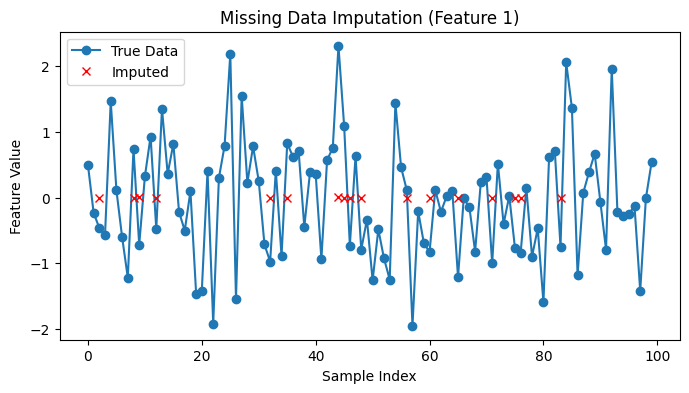

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

np.random.seed(42)
n_samples, n_features = 100, 5
X_complete = np.random.randn(n_samples, n_features)
missing_rate = 0.2
mask = np.random.rand(n_samples, n_features) < missing_rate
X_missing = X_complete.copy()
X_missing[mask] = np.nan

imputer = IterativeImputer(random_state=42)
X_imputed = imputer.fit_transform(X_missing)

plt.figure(figsize=(8,4))
plt.plot(X_complete[:,0], 'o-', label='True Data')
missing_idx = np.where(np.isnan(X_missing[:,0]))[0]
plt.plot(missing_idx, X_imputed[missing_idx,0], 'rx', label='Imputed')
plt.title('Missing Data Imputation (Feature 1)')
plt.xlabel('Sample Index')
plt.ylabel('Feature Value')
plt.legend()
plt.show()


### 5.2 Speech Recognition and Machine Translation

EM is essential in training Hidden Markov Models (HMMs) for speech recognition and in word alignment for machine translation (e.g., IBM Model 1).

#### Pseudocode Example: IBM Model 1 (Word Alignment)

```python
# Pseudocode for IBM Model 1 using EM:
V_source = 1000  # Source vocabulary size
V_target = 1000  # Target vocabulary size
translation_prob = np.full((V_target, V_source), 1.0 / V_source)  # Initialize uniformly

# Example corpus: list of (target_sentence, source_sentence) pairs
corpus = [([12, 45, 78], [34, 89, 12, 45]), ([34, 56, 78], [12, 34, 78])]

for iteration in range(10):
    count = np.zeros_like(translation_prob)
    total_source = np.zeros(V_source)
    
    for target, source in corpus:
        for t_word in target:
            total = sum(translation_prob[t_word, s] for s in source)
            for s in source:
                fraction = translation_prob[t_word, s] / total
                count[t_word, s] += fraction
                total_source[s] += fraction
    
    # M-step: update translation probabilities
    for t in range(V_target):
        for s in range(V_source):
            if total_source[s] > 0:
                translation_prob[t, s] = count[t, s] / total_source[s]
```

In [9]:
import numpy as np

# Define a small synthetic corpus of (target_sentence, source_sentence) pairs.
# For example, consider English as the target language and French as the source language.
corpus = [
    (["the", "house"], ["la", "maison"]),
    (["the", "book"], ["le", "livre"]),
    (["a", "book"], ["un", "livre"])
]

# Create vocabulary lists for both target and source languages.
target_vocab = set()
source_vocab = set()
for (target_sentence, source_sentence) in corpus:
    target_vocab.update(target_sentence)
    source_vocab.update(source_sentence)

target_vocab = list(target_vocab)
source_vocab = list(source_vocab)

# Create word-to-index mappings.
target_to_idx = {word: i for i, word in enumerate(target_vocab)}
source_to_idx = {word: i for i, word in enumerate(source_vocab)}

# Initialize the translation probability matrix.
# translation_prob[t][s] is the probability that target word t is aligned to source word s.
T = len(target_vocab)
S = len(source_vocab)
translation_prob = np.full((T, S), 1.0 / S)  # Uniform initialization

# Set the number of EM iterations.
max_iter = 10

# EM algorithm: iterate between the E-step and the M-step.
for iteration in range(max_iter):
    # Initialize count matrices.
    count = np.zeros((T, S))
    total_source = np.zeros(S)
    
    # E-step: For each sentence pair in the corpus...
    for (target_sentence, source_sentence) in corpus:
        # For each target word in the target sentence...
        for t_word in target_sentence:
            t_index = target_to_idx[t_word]
            # Compute normalization factor: sum of current translation probabilities for the source words.
            total_prob = 0.0
            for s_word in source_sentence:
                s_index = source_to_idx[s_word]
                total_prob += translation_prob[t_index, s_index]
            # Distribute fractional counts for the target word over the source words.
            for s_word in source_sentence:
                s_index = source_to_idx[s_word]
                fraction = translation_prob[t_index, s_index] / total_prob
                count[t_index, s_index] += fraction
                total_source[s_index] += fraction

    # M-step: Update translation probabilities by normalizing counts.
    for t_index in range(T):
        for s_index in range(S):
            # Note: This normalization is one way of updating.
            # Different implementations may use slightly different update formulas.
            if total_source[s_index] > 0:
                translation_prob[t_index, s_index] = count[t_index, s_index] / total_source[s_index]
    
    # Print intermediate output
    print(f"Iteration {iteration+1}")
    print("Translation probabilities (rows: target words, columns: source words):")
    print(np.round(translation_prob, 3))
    print()

# After EM converges, display the learned translations in a human-friendly format.
print("Final Translation Probabilities:\n")
for t_word, t_index in target_to_idx.items():
    probs = translation_prob[t_index, :]
    sorted_indices = np.argsort(probs)[::-1]
    print(f"Target word '{t_word}' translations:")
    for idx in sorted_indices:
        print(f"  {source_vocab[idx]}: {probs[idx]:.4f}")
    print()

Iteration 1
Translation probabilities (rows: target words, columns: source words):
[[0.   0.25 0.5  0.5  0.5 ]
 [0.   0.   0.5  0.   0.5 ]
 [0.5  0.5  0.   0.5  0.  ]
 [0.5  0.25 0.   0.   0.  ]]

Iteration 2
Translation probabilities (rows: target words, columns: source words):
[[0.    0.2   0.5   0.571 0.5  ]
 [0.    0.    0.5   0.    0.5  ]
 [0.429 0.6   0.    0.429 0.   ]
 [0.571 0.2   0.    0.    0.   ]]

Iteration 3
Translation probabilities (rows: target words, columns: source words):
[[0.    0.154 0.5   0.64  0.5  ]
 [0.    0.    0.5   0.    0.5  ]
 [0.36  0.692 0.    0.36  0.   ]
 [0.64  0.154 0.    0.    0.   ]]

Iteration 4
Translation probabilities (rows: target words, columns: source words):
[[0.    0.114 0.5   0.702 0.5  ]
 [0.    0.    0.5   0.    0.5  ]
 [0.298 0.772 0.    0.298 0.   ]
 [0.702 0.114 0.    0.    0.   ]]

Iteration 5
Translation probabilities (rows: target words, columns: source words):
[[0.    0.081 0.5   0.756 0.5  ]
 [0.    0.    0.5   0.    0.5  ]
 [0

### 5.3 Image Segmentation and Reconstruction

EM is used in medical imaging and computer vision for tasks such as image segmentation by fitting a Gaussian Mixture Model (GMM) to pixel intensities.


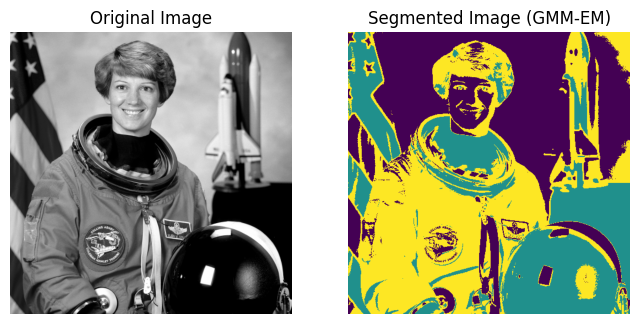

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2gray
from sklearn.mixture import GaussianMixture

image = rgb2gray(data.astronaut())
X_image = image.reshape(-1, 1)

gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X_image)
labels_img = gmm.predict(X_image)
segmented_img = labels_img.reshape(image.shape)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(segmented_img, cmap='viridis')
plt.title('Segmented Image (GMM-EM)')
plt.axis('off')
plt.show()


### 5.4 Robust Statistics (Mixtures of t-Distributions)

EM can be applied to mixtures of heavy-tailed distributions (like the Student’s t-distribution) for robust estimation in the presence of outliers. Below is a full code example for a univariate mixture of t‑distributions.

Estimated mixing coefficients: [0.41467828 0.58532172]
Estimated means: [ 4.90575467e+00 -4.26912976e-03]
Estimated variances: [2.32583875 0.90663164]


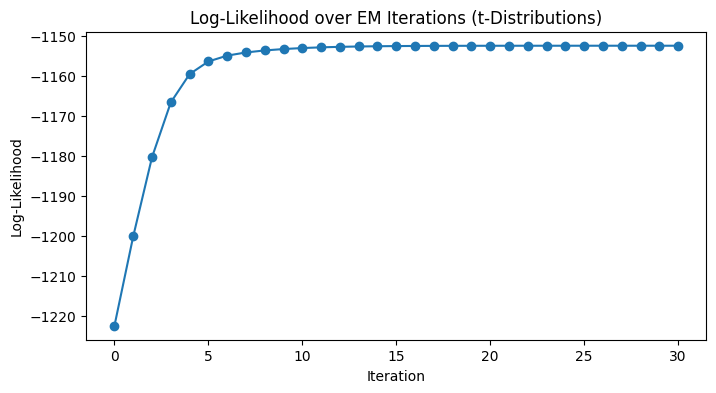

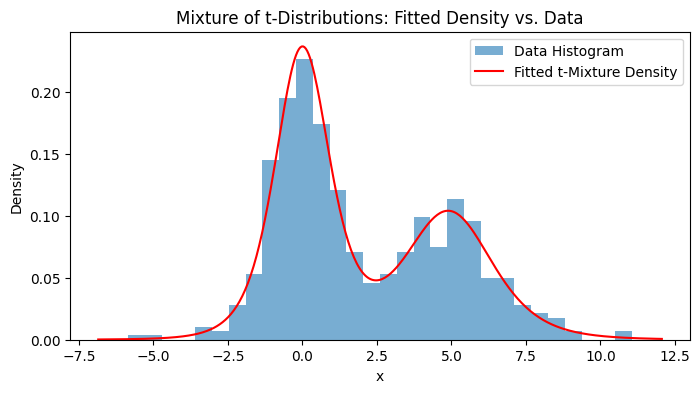

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

def t_pdf(x, mu, sigma2, nu):
    sigma = np.sqrt(sigma2)
    coeff = gamma((nu+1)/2) / (gamma(nu/2)*np.sqrt(nu*np.pi)*sigma)
    return coeff * (1 + (1/nu)*((x-mu)/sigma)**2) ** (-(nu+1)/2)

def log_likelihood_t_mixture(X, pi, mu, sigma2, nu):
    n = len(X)
    ll = 0.0
    for i in range(n):
        temp = 0
        for k in range(len(pi)):
            temp += pi[k] * t_pdf(X[i], mu[k], sigma2[k], nu)
        ll += np.log(temp)
    return ll

def em_t_mixture(X, K=2, nu=5, max_iter=100, tol=1e-4):
    n = len(X)
    pi = np.ones(K) / K
    mu = np.random.choice(X, K)
    sigma2 = np.full(K, np.var(X))
    ll_history = []
    for iteration in range(max_iter):
        r = np.zeros((n, K))
        w = np.zeros((n, K))
        for i in range(n):
            for k in range(K):
                r[i, k] = pi[k] * t_pdf(X[i], mu[k], sigma2[k], nu)
            r[i, :] /= np.sum(r[i, :])
            for k in range(K):
                delta = ((X[i]-mu[k])**2) / sigma2[k]
                w[i, k] = (nu+1) / (nu+delta)
        for k in range(K):
            N_k = np.sum(r[:, k])
            mu[k] = np.sum(r[:, k] * w[:, k] * X) / np.sum(r[:, k] * w[:, k])
            sigma2[k] = np.sum(r[:, k] * w[:, k] * (X - mu[k])**2) / np.sum(r[:, k])
            pi[k] = N_k / n
        ll = log_likelihood_t_mixture(X, pi, mu, sigma2, nu)
        ll_history.append(ll)
        if iteration > 0 and abs(ll_history[-1]-ll_history[-2]) < tol:
            break
    return pi, mu, sigma2, ll_history

def generate_t_mixture(n, pi, mu, sigma2, nu):
    X = np.zeros(n)
    components = np.random.choice(len(pi), size=n, p=pi)
    for i in range(n):
        k = components[i]
        z = np.random.randn()
        v = np.random.chisquare(nu)
        X[i] = mu[k] + np.sqrt(sigma2[k]) * z / np.sqrt(v/nu)
    return X, components

np.random.seed(42)
n_samples = 500
true_pi = np.array([0.6, 0.4])
true_mu = np.array([0, 5])
true_sigma2 = np.array([1, 2])
nu = 5
X_t, true_components = generate_t_mixture(n_samples, true_pi, true_mu, true_sigma2, nu)

pi_est, mu_est, sigma2_est, ll_history = em_t_mixture(X_t, K=2, nu=nu, max_iter=100, tol=1e-4)

print('Estimated mixing coefficients:', pi_est)
print('Estimated means:', mu_est)
print('Estimated variances:', sigma2_est)

plt.figure(figsize=(8,4))
plt.plot(ll_history, marker='o')
plt.title('Log-Likelihood over EM Iterations (t-Distributions)')
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.show()

x_vals = np.linspace(np.min(X_t)-1, np.max(X_t)+1, 400)
density = np.zeros_like(x_vals)
for k in range(2):
    density += pi_est[k] * np.array([t_pdf(x, mu_est[k], sigma2_est[k], nu) for x in x_vals])

plt.figure(figsize=(8,4))
plt.hist(X_t, bins=30, density=True, alpha=0.6, label='Data Histogram')
plt.plot(x_vals, density, 'r-', label='Fitted t-Mixture Density')
plt.title('Mixture of t-Distributions: Fitted Density vs. Data')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.show()


### 5.5 Factor Analysis and Co-Clustering

EM is used for dimensionality reduction and clustering via factor analysis.

#### Code Example: Factor Analysis using scikit-learn

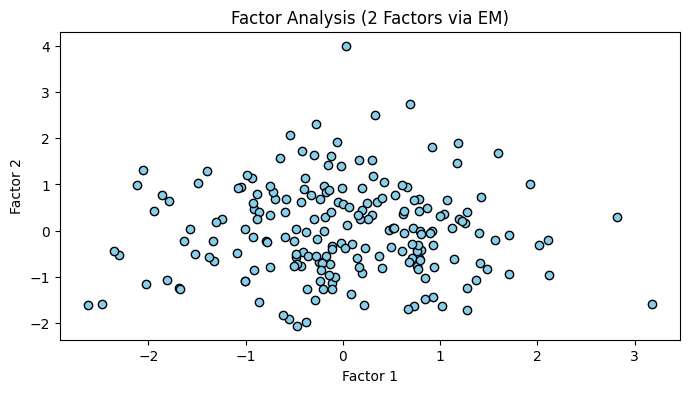

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import FactorAnalysis

np.random.seed(42)
n_samples, n_features, n_factors = 200, 10, 2
factors = np.random.randn(n_samples, n_factors)
loadings = np.random.randn(n_features, n_factors)
noise = np.random.randn(n_samples, n_features) * 0.1
X = factors.dot(loadings.T) + noise

fa = FactorAnalysis(n_components=n_factors, random_state=42)
fa.fit(X)
X_transformed = fa.transform(X)

plt.figure(figsize=(8,4))
plt.scatter(X_transformed[:,0], X_transformed[:,1], color='skyblue', edgecolor='k')
plt.title('Factor Analysis (2 Factors via EM)')
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.show()

### 5.6 Censored Data and Survival Analysis

EM is well-suited for censored data, such as in survival analysis. For example, in right-censored data, we only know that the event time exceeds a threshold. EM treats these censored values as latent and computes their expected contributions.

#### Explanation:

- **Right-Censoring:** The actual event time is greater than a known censoring time.
- **EM Application:** In the E-step, compute the expected value for censored observations based on the current parameter estimates; in the M-step, update parameters accordingly.

Below is an example using an exponential survival model with right-censored data.


Estimated lambda: 0.5739


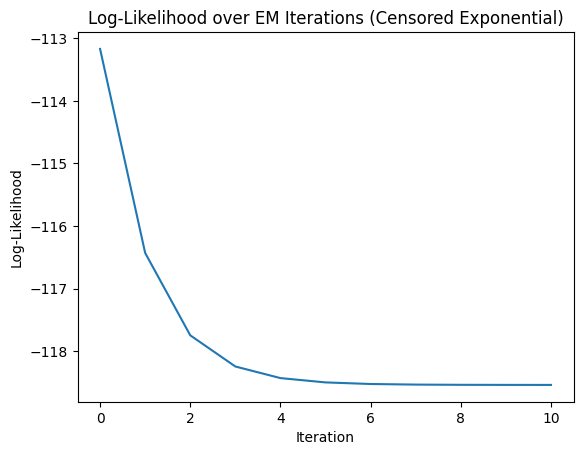

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic exponential data with right-censoring
np.random.seed(42)
true_lambda = 0.5
n = 100
T = np.random.exponential(scale=1/true_lambda, size=n)
C = np.random.exponential(scale=3, size=n)  # censoring times
observed = np.minimum(T, C)
is_censored = T > C

# EM algorithm to estimate lambda
lambda_est = 1.0  # initial guess
ll_history = []

for iteration in range(100):
    # E-step: Compute expected total time
    expected_sum = np.sum(observed[~is_censored]) + np.sum(1 / lambda_est + observed[is_censored])
    n_total = len(T)
    
    # M-step: update lambda
    lambda_new = n_total / expected_sum
    ll = np.sum(np.log(lambda_new) - lambda_new * observed)
    ll_history.append(ll)
    
    if abs(lambda_new - lambda_est) < 1e-5:
        break
    lambda_est = lambda_new

print(f"Estimated lambda: {lambda_est:.4f}")

plt.plot(ll_history)
plt.title("Log-Likelihood over EM Iterations (Censored Exponential)")
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.show()


## 6. Conclusion

EM is a versatile algorithm for parameter estimation in the presence of incomplete or latent data. Its theoretical guarantees—such as monotonic likelihood increase and asymptotic normality—combined with numerous practical and computational extensions, make it a core tool in many fields including missing data imputation, speech recognition, image segmentation, robust statistics, factor analysis, and survival analysis with censored data.

### Key Takeaways:

- **Theoretical Foundations:** EM decomposes the log-likelihood using the KL divergence, ensuring non-decreasing updates. Its convergence rate depends on the ratio of missing to observed information.
- **Practical Considerations:** Effective initialization, convergence diagnostics, numerical stability, and computational efficiency are essential for successful implementation.
- **Extensions and Variants:** Many variants (VB‑EM, MAP EM, ECM/ECME/PX‑EM, MCEM/SAEM, Alpha‑EM, AECM) have been developed to address various challenges and improve convergence behavior.
- **Broad Applications:** EM has been successfully applied in diverse domains ranging from clustering and sequence modeling to robust estimation and survival analysis.

A thorough understanding and careful implementation of EM enables robust and effective analysis across many application areas.

### References

- Dempster, A. P., Laird, N. M., & Rubin, D. B. (1977). *Maximum Likelihood from Incomplete Data via the EM Algorithm*. JRSSB.
- Bilmes, J. A. (1998). *A Gentle Tutorial of the EM Algorithm*.
- Gupta, M. R., & Chen, Y. (2010). *Theory and Use of the EM Algorithm*, Foundations and Trends in Signal Processing.
- Meng, X.-L., & van Dyk, D. (1997). *The EM Algorithm—An Old Folk-Song Sung to a Fast New Tune*. JRSSB.
- Rabiner, L. R. (1989). *A Tutorial on Hidden Markov Models and Selected Applications in Speech Recognition*. Proceedings of the IEEE.
- Roche, A. (2012). *EM Algorithm and Variants: An Informal Tutorial* (arXiv:1105.1476v2).